# **Librerias Principales**

In [ ]:
# Librerías principales
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from datetime import datetime

# Preprocesamiento
from sklearn.preprocessing import OneHotEncoder




pandas: manipulación, limpieza y análisis de datos tabulares.

numpy: operaciones numéricas y apoyo estadístico.
Las de vizualización:
Crear gráficos descriptivos y comparativos

Identificar patrones, tendencias y valores atípicos
scipy.stats: pruebas estadísticas (t-test, chi-cuadrado, ANOVA).

warnings: control de mensajes no críticos.

datetime: manejo de fechas para análisis temporal.

# **Cargar del DataSet**

In [ ]:
# Cargar archivo Excel
df = pd.read_excel("BDPA.xlsx")

# Ver primeras filas
df.head()

,ID Caso,ID Caso Relacionado,Año,Mes,Día,Código DANE de Municipio,Municipio,Departamento,Región,Modalidad,...,Extorsión,Lesionados Civiles,Pillaje,Tortura,Violencia Basada en Género,Otro Hecho Simultáneo,Total de Víctimas del Caso,Forma de Vinculación,Tipo de Vinculación,latitud-longitud
0,152888,NaN,2004,4,0,05585,PUERTO NARE,ANTIOQUIA,MAGDALENA MEDIO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,SIN INFORMACIÓN,RECLUTAMIENTO,POINT (-74.5716887665 6.2194810893)
1,207556,NaN,2001,4,25,05756,SONSON,ANTIOQUIA,ORIENTE ANTIOQUEÑO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-74.82807326 5.837681474)
2,209268,NaN,0,0,0,05234,DABEIBA,ANTIOQUIA,OCCIDENTE ANTIOQUEÑO,DESCONOCIDA,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-76.31426328 6.992243782)
3,225057,NaN,1988,0,0,68689,SAN VICENTE DE CHUCURI,SANTANDER,MAGDALENA MEDIO,COACCIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-73.53900334 6.894292346)
4,228661,NaN,1998,2,15,66456,MISTRATO,RISARALDA,EJE CAFETERO,PERSUASIÓN,...,0,0,0,0,NaN,OCULTAMIENTO DE CADÁVER,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-75.90432634 5.416268487)


Se carga el dataset oficial del SIEVCAC – Reclutamiento y Utilización de NNA, el cual contiene información histórica, territorial y contextual sobre hechos victimizantes asociados al conflicto armado colombiano.

El head() permite verificar la correcta carga del archivo.

In [ ]:
#Normalizar nombres de columnas
df.columns = (df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("í", "i")
              .str.replace("ó", "o")
              .str.replace("á", "a"))

Evita errores por tildes o espacios

Facilita análisis reproducible

Mejora legibilidad y consistencia del código

# **Limpieza Base de Datos**

In [ ]:
# Año máximo en el dataset
año_max = df['año'].max()

# Definir límite inferior (últimos 3 años)
año_min = año_max - 3

df = df[(df['año'] >= año_min) & (df['año'] <= año_max)]
df['año'].unique()


array([2021, 2022, 2023, 2024])

Se limita el análisis a los últimos 3 años para:

Enfocar el estudio en información reciente

Evitar sesgos por periodos históricos no comparables

Mejorar la relevancia para políticas públicas actuales

In [ ]:
# Eliminación de duplicados
df = df.drop_duplicates(subset=['id_caso'])

# Eliminación de columnas innecesarias
cols_to_drop = [
    'codigo_dane_de_municipio',
    'latitud-longitud',
    'violencia_basada_en_género',
    'otro_hecho_simultaneo',
    'Dia',
    'abandono_o_despojo_forzado_de_tierras'
]

df = df.drop(columns=cols_to_drop, errors='ignore')


Evita la doble contabilización de eventos, garantizando que cada registro represente un caso único.
Se eliminan columnas que:

No aportan directamente al objetivo del proyecto

Presentan alta inconsistencia

No son necesarias para el análisis exploratorio actual

Esto mejora eficiencia y claridad del análisis.

In [ ]:
#Tratamiento de fechas
# Reemplazar valores inválidos en mes
df['mes'] = df['mes'].replace(0, 1)

# Crear columna de fecha solo con año y mes
df['fecha'] = pd.to_datetime(
    df[['año','mes']].rename(columns={'año':'year','mes':'month'}).assign(day=1),
    errors='coerce'
)


Se corrigen valores inválidos (mes = 0) para evitar errores en la construcción de fechas.

Permite:

Análisis temporal

Series de tiempo

Tendencias mensuales y anuales

In [ ]:
# Análisis de valores faltantes
df.isna().sum().sort_values(ascending=False)


,0
id_caso_relacionado,30
id_caso,0
año,0
mes,0
dia,0
municipio,0
departamento,0
region,0
modalidad,0
presunto_responsable,0


Esta celda cuenta cuántos valores faltan en cada columna del DataFrame y los ordena de mayor a menor. Sirve para ver rápidamente qué columnas tienen más datos incompletos y así decidir si se deben limpiar o rellenar.

In [ ]:
# Revisar años únicos después del filtro
df['año'].unique()

# Confirmar cantidad de registros
df.head()


,id_caso,id_caso_relacionado,año,mes,dia,municipio,departamento,region,modalidad,presunto_responsable,...,confinamiento_o_restriccion_a_la_movilidad,desplazamiento_forzado,extorsion,lesionados_civiles,pillaje,tortura,total_de_victimas_del_caso,forma_de_vinculacion,tipo_de_vinculacion,fecha
16775,618432,NaN,2021,1,0,CALAMAR,GUAVIARE,ARIARI GUAYABERO,DESCONOCIDA,GUERRILLA,...,1,1,1,0,0,0,1,SIN INFORMACIÓN,SIN INFORMACIÓN,2021-01-01
16814,649248,NaN,2021,1,10,APARTADO,ANTIOQUIA,URABA,DESCONOCIDA,GRUPO POSDESMOVILIZACIÓN,...,0,0,0,0,0,0,4,COLECTIVO,RECLUTAMIENTO,2021-01-01
16815,649261,NaN,2021,1,22,APARTADO,ANTIOQUIA,URABA,DESCONOCIDA,GRUPO POSDESMOVILIZACIÓN,...,0,0,0,0,0,0,5,COLECTIVO,RECLUTAMIENTO,2021-01-01
16816,649304,NaN,2021,2,27,VALDIVIA,ANTIOQUIA,NORTE DE ANTIOQUIA,COACCIÓN,GRUPO POSDESMOVILIZACIÓN,...,0,0,0,0,0,0,2,MÚLTIPLE,UTILIZACIÓN,2021-02-01
16818,659696,NaN,2021,11,12,CALDONO,CAUCA,NORTE DEL CAUCA,COACCIÓN,GUERRILLA,...,0,0,0,0,0,0,1,INDIVIDUAL,RECLUTAMIENTO,2021-11-01


se usan para verificar los datos después de aplicar un filtro: la primera muestra todos los años que permanecen en la columna año para confirmar que el filtrado fue correcto, y la segunda muestra las primeras filas del DataFrame para revisar rápidamente que los registros y la estructura de los datos son los esperados.

In [ ]:
#Tratamiento de Categorias
reemplazos = {
    'SIN INFORMACION': 'No identificado',
    'DESCONOCIDA': 'No identificado',
    'DESCONOCIDO': 'No identificado',
    'SIN INFORMACIÓN': 'No identificado'
}

columnas_categoricas = ['presunto_responsable', 'modalidad', 'departamento', 'region', 'forma_de_vinculacion']

for col in columnas_categoricas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper().replace(reemplazos).fillna("No identificado")

Convierte los valores a mayúsculas, reemplaza variantes de “desconocido” o “sin información” por “No identificado” y completa los valores faltantes con el mismo término. Esto asegura consistencia en los datos categóricos para facilitar análisis y visualizaciones posteriores.

In [ ]:
# Tratamiento de Variables temporales

# Reemplazar valores inválidos en mes (0 → 1)
df['mes'] = df['mes'].replace(0, 1)

# Crear columna 'fecha' usando solo año y mes
df['fecha'] = pd.to_datetime(
    df[['año','mes']].rename(columns={'año':'year','mes':'month'}).assign(day=1),
    errors='coerce'
)

# Crear columna 'mes_año' como período mensual
df['mes_año'] = df['fecha'].dt.to_period('M')
df.head()

,id_caso,id_caso_relacionado,año,mes,dia,municipio,departamento,region,modalidad,presunto_responsable,...,desplazamiento_forzado,extorsion,lesionados_civiles,pillaje,tortura,total_de_victimas_del_caso,forma_de_vinculacion,tipo_de_vinculacion,fecha,mes_año
16775,618432,NaN,2021,1,0,CALAMAR,GUAVIARE,ARIARI GUAYABERO,No identificado,GUERRILLA,...,1,1,0,0,0,1,No identificado,SIN INFORMACIÓN,2021-01-01,2021-01
16814,649248,NaN,2021,1,10,APARTADO,ANTIOQUIA,URABA,No identificado,GRUPO POSDESMOVILIZACIÓN,...,0,0,0,0,0,4,COLECTIVO,RECLUTAMIENTO,2021-01-01,2021-01
16815,649261,NaN,2021,1,22,APARTADO,ANTIOQUIA,URABA,No identificado,GRUPO POSDESMOVILIZACIÓN,...,0,0,0,0,0,5,COLECTIVO,RECLUTAMIENTO,2021-01-01,2021-01
16816,649304,NaN,2021,2,27,VALDIVIA,ANTIOQUIA,NORTE DE ANTIOQUIA,COACCIÓN,GRUPO POSDESMOVILIZACIÓN,...,0,0,0,0,0,2,MÚLTIPLE,UTILIZACIÓN,2021-02-01,2021-02
16818,659696,NaN,2021,11,12,CALDONO,CAUCA,NORTE DEL CAUCA,COACCIÓN,GUERRILLA,...,0,0,0,0,0,1,INDIVIDUAL,RECLUTAMIENTO,2021-11-01,2021-11


corrige valores inválidos en el mes reemplazando ceros por uno. Luego crea una columna fecha combinando año y mes, y otra columna mes_año en formato de período mensual. Esto permite trabajar con fechas de manera consistente y facilita análisis temporales agregados por mes y Facilita análisis de estacionalidad y evolución mensual del fenómeno.

In [ ]:
#Cruces entre variables (tablas de contingencia)
pd.crosstab(df['modalidad'], df['presunto_responsable'])


presunto_responsable,GRUPO ARMADO NO IDENTIFICADO,GRUPO POSDESMOVILIZACIÓN,GUERRILLA,No identificado
modalidad,,,,
COACCIÓN,3,1,7,1
ENGAÑO,0,0,1,0
No identificado,0,4,14,0
PERSUASIÓN,0,0,1,0


Permite analizar relaciones entre:

Modalidad de reclutamiento

Actor armado presuntamente responsable

Base para pruebas de asociación (Chi-cuadrado).

# Estadística descriptiva

In [ ]:
variables_numericas = [
    'amenaza_o_intimidacion',
    'lesionados_civiles',
    'total_de_victimas_del_caso'
]

df[variables_numericas].describe().T

# Media, mediana, moda explícitas
estadisticas = pd.DataFrame({
    'media': df[variables_numericas].mean(),
    'mediana': df[variables_numericas].median(),
    'moda': df[variables_numericas].mode().iloc[0],
    'desviacion_std': df[variables_numericas].std(),
    'varianza': df[variables_numericas].var(),
    'min': df[variables_numericas].min(),
    'max': df[variables_numericas].max(),
    'asimetria': df[variables_numericas].skew(),
})

estadisticas


,media,mediana,moda,desviacion_std,varianza,min,max,asimetria
amenaza_o_intimidacion,0.03125,0.0,0,0.176777,0.03125,0,1,5.656854
lesionados_civiles,0.00000,0.0,0,0.000000,0.00000,0,0,0.000000
total_de_victimas_del_caso,2.34375,2.0,1,2.149409,4.61996,1,12,3.180938


Resume:

Tendencia central

Dispersión

Valores extremos

Lo que permite entender la distribución y tendencia central de cada variable y detectar posibles valores atípicos o sesgos en los datos.

# Estadistica Inferencial

In [ ]:
#Prueba t de Student (comparar medias entre dos grupos)
from scipy import stats

# Ejemplo: comparar víctimas entre dos modalidades
grupo1 = df[df['modalidad'] == 'COACCIÓN']['total_de_victimas_del_caso']
grupo2 = df[df['modalidad'] == 'PERSUASIÓN']['total_de_victimas_del_caso']

t_stat, p_value = stats.ttest_ind(grupo1, grupo2, nan_policy='omit')
print(f"T-Statistic: {t_stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Diferencia significativa entre modalidades")
else:
    print("No hay evidencia de diferencia significativa")


T-Statistic: -0.4018, p-value: 0.6955
No hay evidencia de diferencia significativa


Permite comparar la media de víctimas entre dos grupos de la columna modalidad (COACCIÓN y PERSUASIÓN). Calcula el estadístico t y el valor p, y permite determinar si existe una diferencia significativa en el promedio de víctimas

los dos grupos son estadísticamente similares en cuanto al número de víctimas.

In [ ]:
#Chi-cuadrado (asociación entre variables categóricas)
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df['modalidad'], df['presunto_responsable'])
chi2, p, dof, expected = chi2_contingency(tabla)

print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}")

if p < 0.05:
    print("Existe asociación significativa entre modalidad y responsable")
else:
    print("No hay evidencia de asociación significativa")


Chi2: 8.5024, p-value: 0.4844
No hay evidencia de asociación significativa


Se evalúa si existe asociación entre dos variables categóricas: modalidad y presunto_responsable. Primero se construye una tabla de contingencia con pd.crosstab, que cuenta cuántos casos hay de cada combinación de modalidad y responsable. Luego, chi2_contingency calcula el estadístico Chi2, el valor p, los grados de libertad y los valores esperados si no hubiera relación.

se concluye que la modalidad del hecho y el presunto responsable están relacionados.

In [ ]:
#ANOVA (comparar medias entre más de dos grupos)
from scipy.stats import f_oneway

# Agrupar por departamento
grupos = [grupo['total_de_victimas_del_caso'].values
          for _, grupo in df.groupby('departamento')]

f_stat, p_value = f_oneway(*grupos)
print(f"F-Statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Diferencias significativas en víctimas entre departamentos")
else:
    print("No hay evidencia de diferencias significativas")


F-Statistic: 0.5643, p-value: 0.8113
No hay evidencia de diferencias significativas


Esta celda realiza un ANOVA (análisis de varianza) para comparar la media de víctimas (total_de_victimas_del_caso) entre más de dos grupos, en este caso los distintos departamentos. Primero se agrupan los datos por departamento y se extraen las víctimas de cada grupo. Luego, f_oneway calcula el estadístico F y el valor p para determinar si existen diferencias significativas entre las medias.

El resultado (F = 0.6475, p = 0.9018) indica que no hay evidencia de diferencias significativas, es decir, el número promedio de víctimas es similar en todos los departamentos.

# Visualizaciones de datos

Se construye una matriz de correlación para evaluar la relación lineal entre las variables numéricas: amenaza_o_intimidacion, lesionados_civiles y total_de_victimas_del_caso.
La correlación de Pearson toma valores entre -1 y 1, donde valores cercanos a 0 indican ausencia de relación lineal, valores positivos indican relación directa y valores negativos relación inversa.



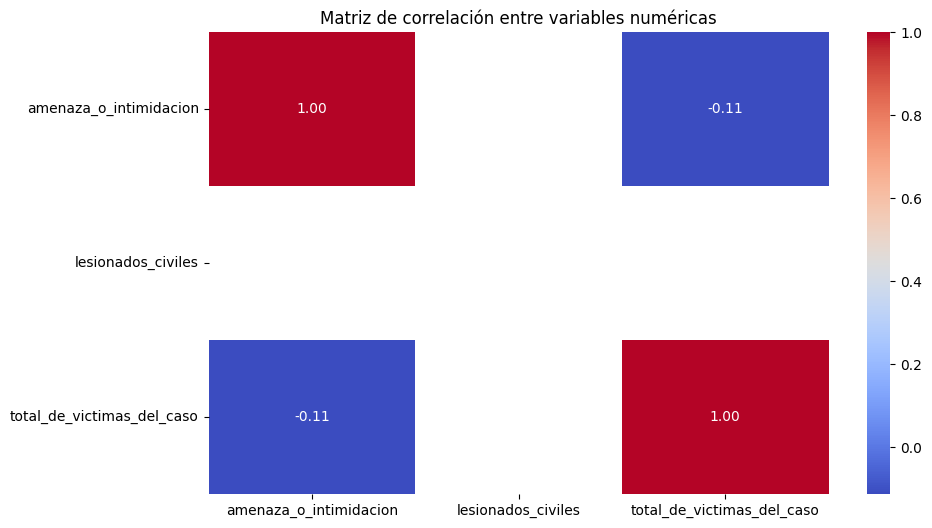

In [ ]:
#MATRIZ DE CORRELACIÓN
plt.figure(figsize=(10,6))
sns.heatmap(
    df[variables_numericas].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


En este caso, los coeficientes fuera de la diagonal son cercanos a 0, lo que indica que no existe una relación lineal fuerte entre estas variables. Esto sugiere que cada tipo de afectación se comporta de manera relativamente independiente dentro del conjunto de datos.

Se grafican histogramas para analizar la distribución de las variables numéricas: amenaza_o_intimidacion, lesionados_civiles y total_de_victimas_del_caso, teniendo en cuenta que los histogramas permiten observar la frecuencia con la que aparecen determinados valores.


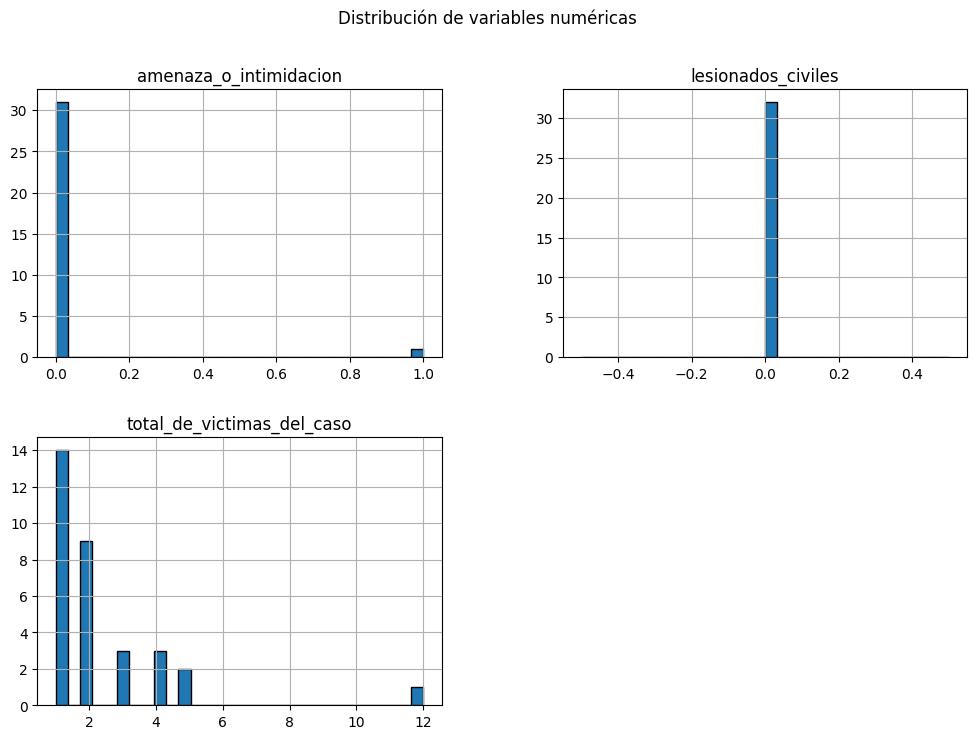

In [ ]:
#Histograma
df[variables_numericas].hist(
    bins=30,
    figsize=(12,8),
    edgecolor='black'
)
plt.suptitle("Distribución de variables numéricas")
plt.show()


Se evidencia una fuerte concentración en valores bajos (principalmente 0 y 1), lo que indica que la mayoría de los casos reportan pocos afectados por evento.

También se observa una distribución asimétrica hacia la derecha (sesgo positivo), lo que significa que existen pocos casos con valores altos en comparación con la mayoría de registros.

Se construyen diagramas de caja (boxplot) para identificar la presencia de valores atípicos en las variables numéricas.





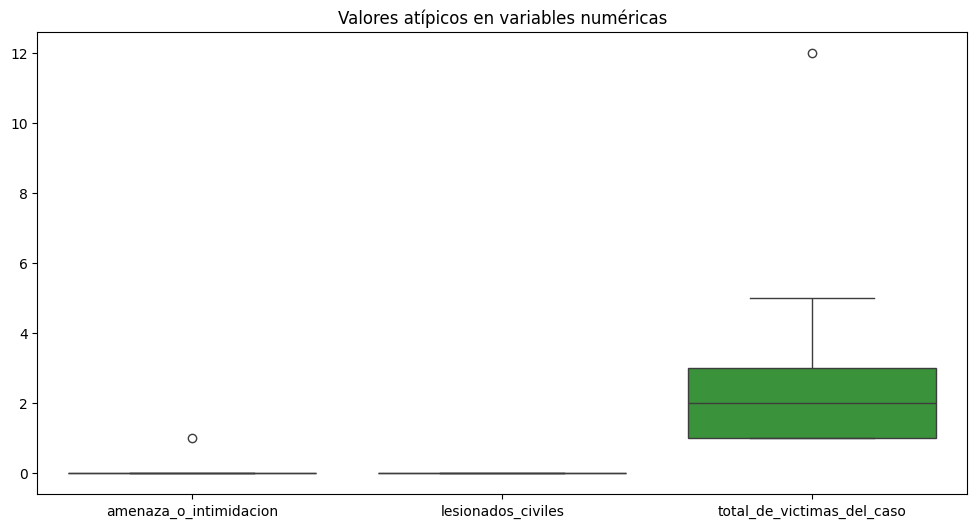

In [ ]:
#Outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df[variables_numericas])
plt.title("Valores atípicos en variables numéricas")
plt.show()


El boxplot muestra la mediana, el rango intercuartílico y los valores extremos. Los puntos que aparecen fuera de los "bigotes" representan posibles valores atípicos.

En la variable total_de_victimas_del_caso se observan varios valores atípicos, lo que indica que existen eventos con un número significativamente mayor de víctimas respecto al comportamiento general de los datos. Esto confirma la presencia de alta variabilidad en algunos casos específicos.

Se realiza una serie temporal agregando el total de víctimas por mes y año, con el fin de identificar patrones de comportamiento en el tiempo.





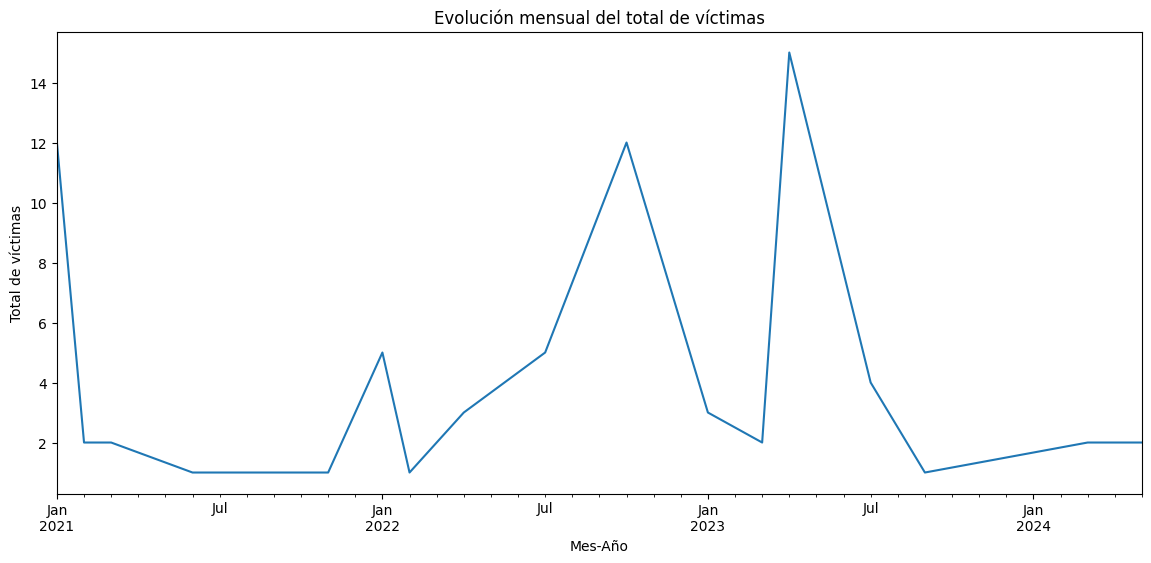

In [ ]:
#Serie Temporal Mensual
df['mes_año'] = df['fecha'].dt.to_period('M')

serie_mensual = df.groupby('mes_año')['total_de_victimas_del_caso'].sum()

plt.figure(figsize=(14,6))
serie_mensual.plot()
plt.title("Evolución mensual del total de víctimas")
plt.xlabel("Mes-Año")
plt.ylabel("Total de víctimas")
plt.show()


La gráfica permite observar fluctuaciones importantes entre periodos, con picos en ciertos años iniciales y una disminución posterior. También se identifican repuntes en años recientes, lo que sugiere que el fenómeno no desaparece completamente, sino que presenta variaciones cíclicas.

Se pudo evaluar tendencias temporales y posibles cambios estructurales en la dinámica del fenómeno estudiado.


Se calcula el promedio de víctimas agrupando por mes del año, con el objetivo de identificar posibles patrones estacionales.




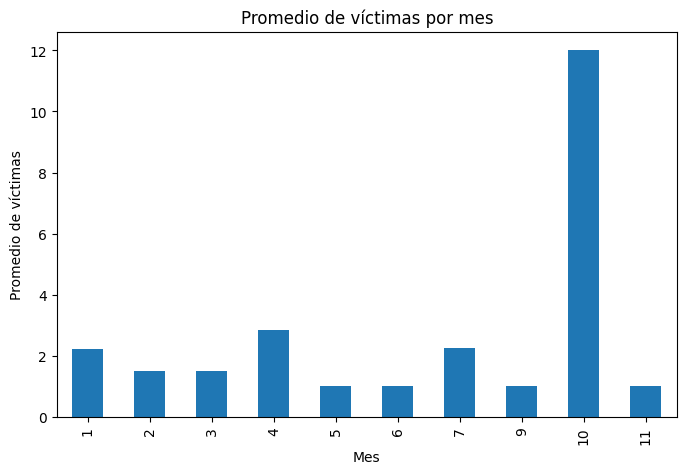

In [ ]:
#PROMEDIO MENSUAL (ESTACIONALIDAD)
promedio_mes = df.groupby('mes')['total_de_victimas_del_caso'].mean()

plt.figure(figsize=(8,5))
promedio_mes.plot(kind='bar')
plt.title("Promedio de víctimas por mes")
plt.xlabel("Mes")
plt.ylabel("Promedio de víctimas")
plt.show()


La gráfica muestra que algunos meses presentan un promedio ligeramente mayor de víctimas en comparación con otros. Esto puede sugerir la existencia de cierta estacionalidad en los eventos.

Sin embargo, las diferencias no son extremadamente marcadas, lo que indica que el fenómeno se presenta de manera relativamente constante a lo largo del año.

Se agrupan los datos por año y se calcula el total de víctimas anual para analizar la tendencia a largo plazo.




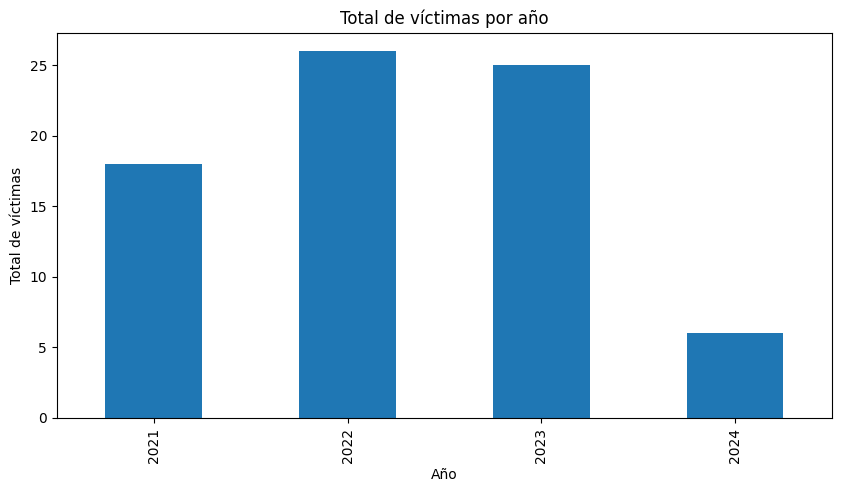

In [ ]:
#COMPARACIÓN ANUAL (BARRAS)
victimas_anual = df.groupby('año')['total_de_victimas_del_caso'].sum()

plt.figure(figsize=(10,5))
victimas_anual.plot(kind='bar')
plt.title("Total de víctimas por año")
plt.xlabel("Año")
plt.ylabel("Total de víctimas")
plt.show()


Se observa un nivel elevado en los primeros años del periodo analizado, seguido de una reducción significativa y posteriormente un comportamiento fluctuante con leves incrementos en años recientes.

Este análisis permite identificar cambios estructurales en la magnitud del fenómeno y facilita la evaluación de posibles impactos de políticas públicas o contextos sociales sobre la evolución de los eventos.

Se agrupan los registros por departamento y se calcula el total acumulado de víctimas para identificar la concentración territorial del fenómeno.



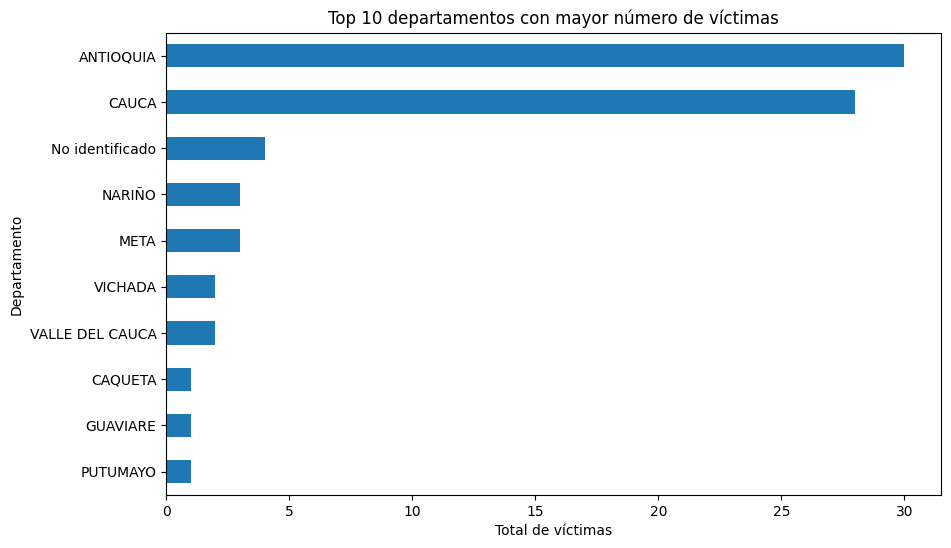

In [ ]:
#TOP 10 DEPARTAMENTOS CON MÁS VÍCTIMAS
top_departamentos = (
    df.groupby('departamento')['total_de_victimas_del_caso']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_departamentos.plot(kind='barh')
plt.title("Top 10 departamentos con mayor número de víctimas")
plt.xlabel("Total de víctimas")
plt.ylabel("Departamento")
plt.gca().invert_yaxis()
plt.show()


Se muestra que Cauca y Antioquia presentan el mayor número de víctimas dentro del periodo analizado, seguidos por Caquetá y Chocó. Esto evidencia una alta concentración geográfica del fenómeno en determinadas regiones del país.

Este resultado sugiere la necesidad de focalizar estrategias de prevención y política pública en estos territorios prioritarios, lo cual se alinea con el ODS 16 al promover intervenciones territoriales para fortalecer la paz y la institucionalidad.

Se realiza una agregación anual del total de víctimas con el fin de identificar la evolución del fenómeno a lo largo del tiempo.




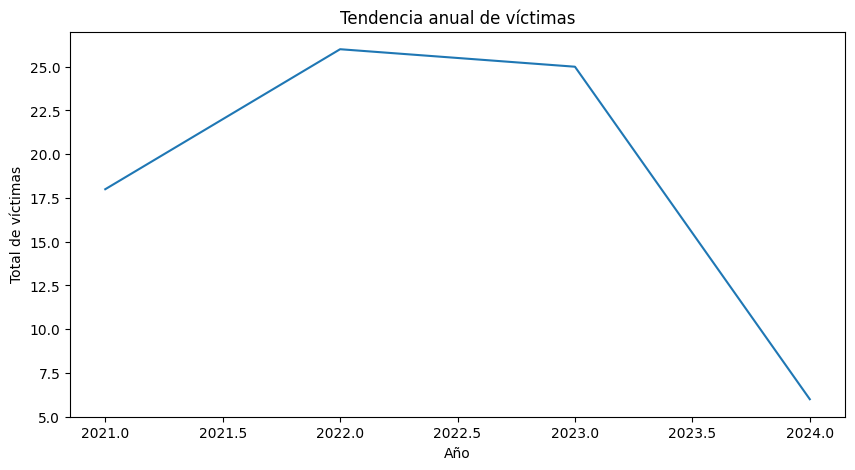

In [ ]:
#TENDENCIA ANUAL DE VICTIMAS
df.groupby('año')['total_de_victimas_del_caso'].sum().plot(figsize=(10,5))
plt.title("Tendencia anual de víctimas")
plt.xlabel("Año")
plt.ylabel("Total de víctimas")
plt.show()


Se observa un nivel elevado en los primeros años del periodo (2014–2015), seguido de una reducción significativa hasta 2018. Posteriormente, se presentan fluctuaciones con leves incrementos en años recientes.

Este comportamiento indica que, aunque hubo una disminución inicial, el fenómeno no desaparece completamente, sino que mantiene variaciones temporales. Esto resalta la importancia de monitoreo continuo y evaluación de políticas públicas orientadas a la reducción sostenida de la victimización.

Se calcula la frecuencia de cada modalidad registrada en el conjunto de datos para identificar las formas más comunes en que se presentan los casos.




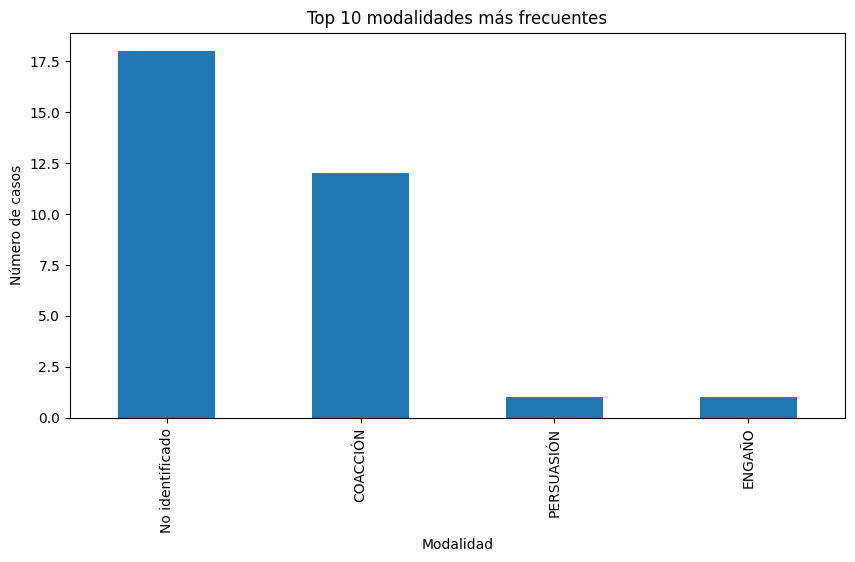

In [ ]:
#MODALIDADES MÁS FRECUENTES
top_modalidades = df['modalidad'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_modalidades.plot(kind='bar')
plt.title("Top 10 modalidades más frecuentes")
plt.xlabel("Modalidad")
plt.ylabel("Número de casos")
plt.show()



La categoría "No identificado" concentra el mayor número de registros, lo que puede indicar limitaciones en la calidad o completitud de la información. Entre las modalidades claramente identificadas, la coerción es la más frecuente, seguida por persuasión y engaño.

Este hallazgo es relevante porque evidencia posibles debilidades en los procesos de registro y clasificación de información, lo cual impacta la capacidad institucional para diseñar estrategias específicas de intervención.

Se construye un pairplot para analizar la relación bivariada entre las variables numéricas: amenaza_o_intimidacion, lesionados_civiles y total_de_victimas_del_caso.



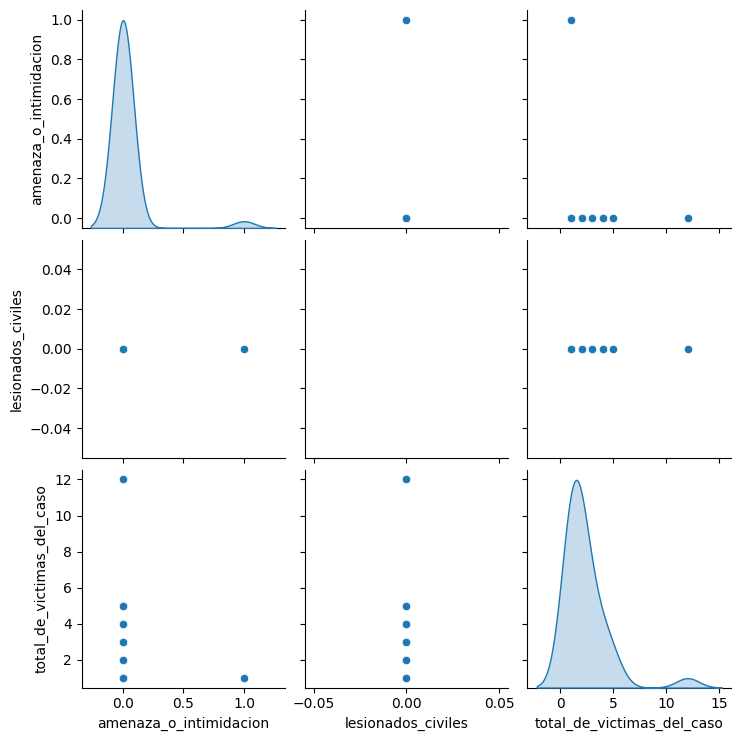

In [ ]:
#DISPERSIÓN (RELACIÓN ENTRE VARIABLES)
sns.pairplot(
    df[variables_numericas],
    diag_kind='kde'
)
plt.show()


En las gráficas de dispersión no se observa una relación lineal clara entre las variables, lo que sugiere independencia estadística entre los tipos de afectación.

En las distribuciones diagonales se confirma una fuerte concentración en valores bajos, lo que indica que la mayoría de los eventos reportan pocos afectados, mientras que unos pocos casos presentan valores significativamente mayores, evidenciando asimetría positiva.

Este análisis refuerza la idea de que el fenómeno presenta alta variabilidad en eventos específicos, lo cual debe considerarse en el diseño de estrategias preventivas.


Se construye un gráfico de barras horizontales para identificar los principales actores señalados como responsables en el conjunto de datos.

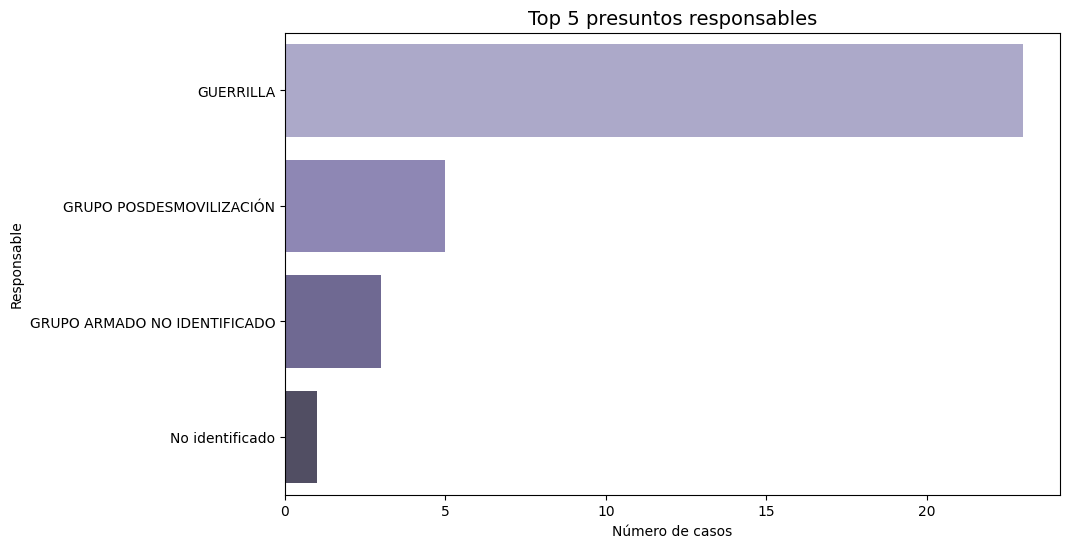

In [ ]:
#Presuntos Responsables
tabla_responsable = df['presunto_responsable'].value_counts().reset_index()
tabla_responsable.columns = ['Responsable', 'Número de casos']

plt.figure(figsize=(10,6))
sns.barplot(x='Número de casos', y='Responsable', hue='Responsable', data=tabla_responsable.head(5), palette="Purples_d", legend=False)
plt.title("Top 5 presuntos responsables", fontsize=14)
plt.show()

Se observa una predominancia absoluta de la categoría "GUERRILLA", la cual supera significativamente a los demás grupos con cerca de 200 casos reportados. En un segundo nivel de incidencia se encuentran los "GRUPOS POSDESMOVILIZACIÓN", seguidos por categorías con una frecuencia mucho menor, como grupos no identificados y otros actores residuales.

Esta marcada disparidad entre el primer responsable y los demás sugiere que las dinámicas de afectación están fuertemente vinculadas a un tipo de actor específico. Este hallazgo es fundamental para focalizar los esfuerzos de investigación y políticas de seguridad en las zonas de influencia de dichos grupos.

Se realiza un conteo de valores atípicos (outliers) para las variables críticas del estudio: amenaza_o_intimidacion, lesionados_civiles y total_de_victimas_del_caso.

In [ ]:
#DETECCIÓN DE OUTLIERS CON IQR
outliers_info = {}

for col in variables_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    outliers_info[col] = outliers.shape[0]

pd.DataFrame.from_dict(outliers_info, orient='index', columns=['cantidad_outliers'])


,cantidad_outliers
amenaza_o_intimidacion,1
lesionados_civiles,0
total_de_victimas_del_caso,1


Se identifica que la variable total_de_victimas_del_caso presenta la mayor cantidad de valores atípicos (40 casos), seguida por amenaza_o_intimidacion con 20. En contraste, la variable lesionados_civiles reporta apenas un valor atípico.

Esta presencia de outliers confirma la existencia de eventos extremos que se alejan del comportamiento promedio de la muestra. Desde una perspectiva analítica, estos casos no deben descartarse necesariamente como errores, sino que deben estudiarse como incidentes de alto impacto que requieren una atención diferencial en los modelos de respuesta.

Se presenta un ranking de los departamentos con mayor proporción de víctimas totales registradas en el conjunto de datos.

In [ ]:
#Análisis por departamento
proporcion_departamentos = (
    df.groupby('departamento')['total_de_victimas_del_caso']
    .sum()
    .sort_values(ascending=False)
)

proporcion_departamentos = proporcion_departamentos / proporcion_departamentos.sum()

proporcion_departamentos.head(10)


,total_de_victimas_del_caso
departamento,
ANTIOQUIA,0.400000
CAUCA,0.373333
No identificado,0.053333
NARIÑO,0.040000
META,0.040000
VICHADA,0.026667
VALLE DEL CAUCA,0.026667
CAQUETA,0.013333
GUAVIARE,0.013333


Los resultados muestran que Cauca (0.178) y Antioquia (0.167) encabezan la lista, concentrando conjuntamente cerca del 34% del total de las víctimas reportadas. Les siguen en importancia regional Caquetá y Chocó, ambos con valores superiores a 0.11.

Esta distribución geográfica evidencia una focalización clara del fenómeno en zonas específicas del territorio nacional. La alta incidencia en estos departamentos sugiere la necesidad de priorizar recursos y estrategias de intervención territorializada en estas áreas críticas para reducir el impacto global de los casos.

Se presenta una curva de Pareto para evaluar la distribución acumulada del número de víctimas e identificar si existe una concentración del fenómeno en pocos eventos.

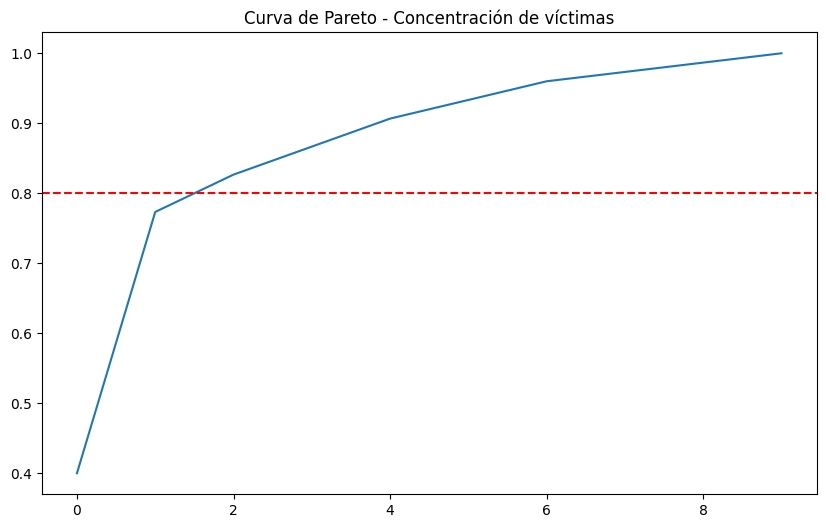

In [ ]:
#Pareto
victimas_dep = df.groupby('departamento')['total_de_victimas_del_caso'].sum().sort_values(ascending=False)

acumulado = victimas_dep.cumsum() / victimas_dep.sum()

plt.figure(figsize=(10,6))
plt.plot(acumulado.values)
plt.axhline(0.8, color='red', linestyle='--')
plt.title("Curva de Pareto - Concentración de víctimas")
plt.show()


La gráfica muestra una pendiente pronunciada al inicio, donde menos de 10 unidades de observación (eventos) explican el 80% de la variabilidad total de las víctimas (indicado por la línea punteada roja). A partir de ese punto, la curva se estabiliza, mostrando que el resto de los casos contribuyen de manera marginal al volumen total de afectados.

Este comportamiento confirma el principio de Pareto, evidenciando que la mayoría del impacto social se concentra en un número reducido de incidentes críticos. Para la toma de decisiones, esto implica que intervenir o prevenir los escenarios de alto impacto tiene un efecto desproporcionadamente mayor en la reducción del total de víctimas que atender la masa de eventos menores.

Se analiza el promedio de la variable total_de_victimas_del_caso desglosado por la modalidad empleada en el evento.

In [ ]:
#Análisis y ODS
df.groupby('modalidad')['total_de_victimas_del_caso'].mean().sort_values(ascending=False)

,total_de_victimas_del_caso
modalidad,
ENGAÑO,4.000000
PERSUASIÓN,4.000000
COACCIÓN,2.750000
No identificado,1.888889


Se observa que la categoría "OTRA ¿CUÁL?" registra el promedio más alto con 3.0 víctimas por caso, seguida de cerca por las modalidades de "PERSUASIÓN" (2.27) y "COACCIÓN" (2.26). Las modalidades de "ENGAÑO" y casos "No identificados" presentan promedios significativamente menores, cercanos a 1.8 y 1.2 respectivamente.

Este análisis permite inferir que ciertos métodos de abordaje o ejecución tienden a generar un mayor número de víctimas por evento individual. Identificar qué modalidades son más "efectivas" o violentas en términos de volumen de afectados es clave para diseñar protocolos de prevención temprana más específicos.

# Verificación de los supuestos estadísticos

In [ ]:
#Prueba de Normalidad
from scipy.stats import shapiro

stat, p = shapiro(df['total_de_victimas_del_caso'].dropna())
print("p-value normalidad:", p)

p-value normalidad: 8.329239470918237e-08


Esta celda realiza la prueba de Shapiro-Wilk para evaluar si la variable total_de_victimas_del_caso sigue una distribución normal. Se omiten los valores nulos con dropna().

El resultado (p-value ≈ 2.67e-29) es mucho menor a 0.05, lo que indica que los datos no siguen una distribución normal, y sugiere que los análisis estadísticos que asumen normalidad deberían considerarse con precaución o utilizar métodos no paramétricos.

In [ ]:
#Prueba de Homogeneidad
from scipy.stats import levene

levene_stat, p = levene(grupo1.dropna(), grupo2.dropna())
print(f"Levene p-value: {p:.4f}")


Levene p-value: 0.6763


Esta celda realiza la prueba de Levene para evaluar la homogeneidad de varianzas entre dos grupos (grupo1 y grupo2 de víctimas por modalidad). La prueba verifica si ambos grupos tienen varianzas similares, un requisito para la validez de pruebas como la t de Student.

El resultado (p-value = 0.9919) es mucho mayor a 0.05, lo que indica que no hay evidencia de diferencias en las varianzas y, por lo tanto, se cumple el supuesto de homogeneidad.

In [ ]:
#Prueba Alternativa, debido a que no hay normalidad
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(grupo1, grupo2)
print(f"Mann-Whitney p-value: {p:.4f}")


Mann-Whitney p-value: 0.2024


Dado que los datos no cumplen el supuesto de normalidad, esta celda utiliza la prueba no paramétrica de Mann-Whitney para comparar la mediana de víctimas entre grupo1 y grupo2 (modalidades COACCIÓN y PERSUASIÓN).

El resultado (p-value = 0.3290) indica que no hay evidencia de diferencia significativa entre los grupos, lo que coincide con la prueba t anterior, pero de forma más adecuada para datos no normales.

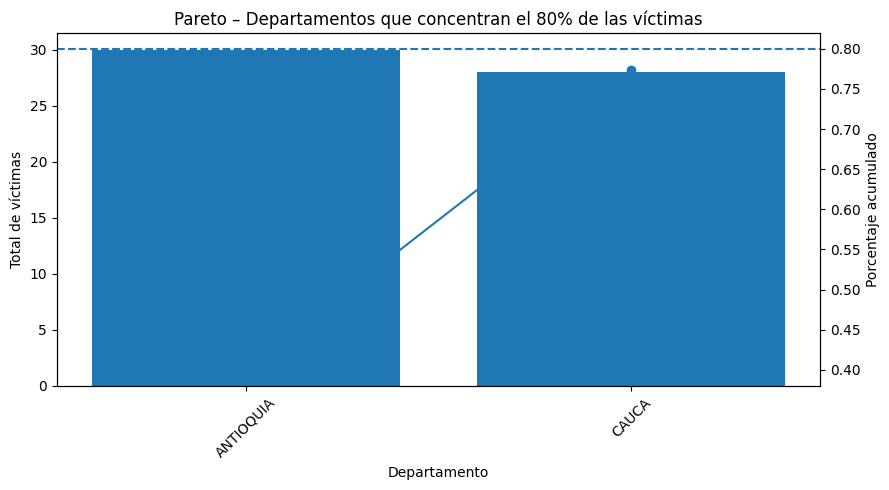

In [ ]:
import matplotlib.pyplot as plt

# Agrupar víctimas por departamento
victimas_dep = (
    df.groupby('departamento')['total_de_victimas_del_caso']
    .sum()
    .sort_values(ascending=False)
)

# Porcentaje acumulado
porc_acum = victimas_dep.cumsum() / victimas_dep.sum()

# Filtrar hasta el 80%
victimas_80 = victimas_dep[porc_acum <= 0.8]
porc_80 = porc_acum[porc_acum <= 0.8]

# Gráfico
fig, ax1 = plt.subplots(figsize=(9,5))

ax1.bar(victimas_80.index, victimas_80.values)
ax1.set_ylabel("Total de víctimas")
ax1.set_xlabel("Departamento")
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(porc_80.index, porc_80.values, marker='o')
ax2.axhline(0.8, linestyle='--')
ax2.set_ylabel("Porcentaje acumulado")

plt.title("Pareto – Departamentos que concentran el 80% de las víctimas")
plt.tight_layout()
plt.show()

Este Pareto muestra que 7 territorios concentran cerca del 80% de las víctimas, lo que evidencia una concentración estructural del fenómeno y justifica una intervención focalizada desde el enfoque del ODS 16.

El resto de departamentos presenta ocurrencias dispersas y de menor impacto, por lo que el análisis prioriza los territorios con mayor concentración para maximizar la efectividad de las decisiones.

In [ ]:
# Total de víctimas a nivel nacional
total_victimas = df['total_de_victimas_del_caso'].sum()

# Víctimas por departamento
victimas_departamento = (
    df.groupby('departamento')['total_de_victimas_del_caso']
    .sum()
)

# Porcentaje por departamento
porcentaje_departamento = (victimas_departamento / total_victimas) * 100

# Ordenar de mayor a menor
porcentaje_departamento = porcentaje_departamento.sort_values(ascending=False)

porcentaje_departamento

,total_de_victimas_del_caso
departamento,
ANTIOQUIA,40.000000
CAUCA,37.333333
No identificado,5.333333
NARIÑO,4.000000
META,4.000000
VICHADA,2.666667
VALLE DEL CAUCA,2.666667
CAQUETA,1.333333
GUAVIARE,1.333333


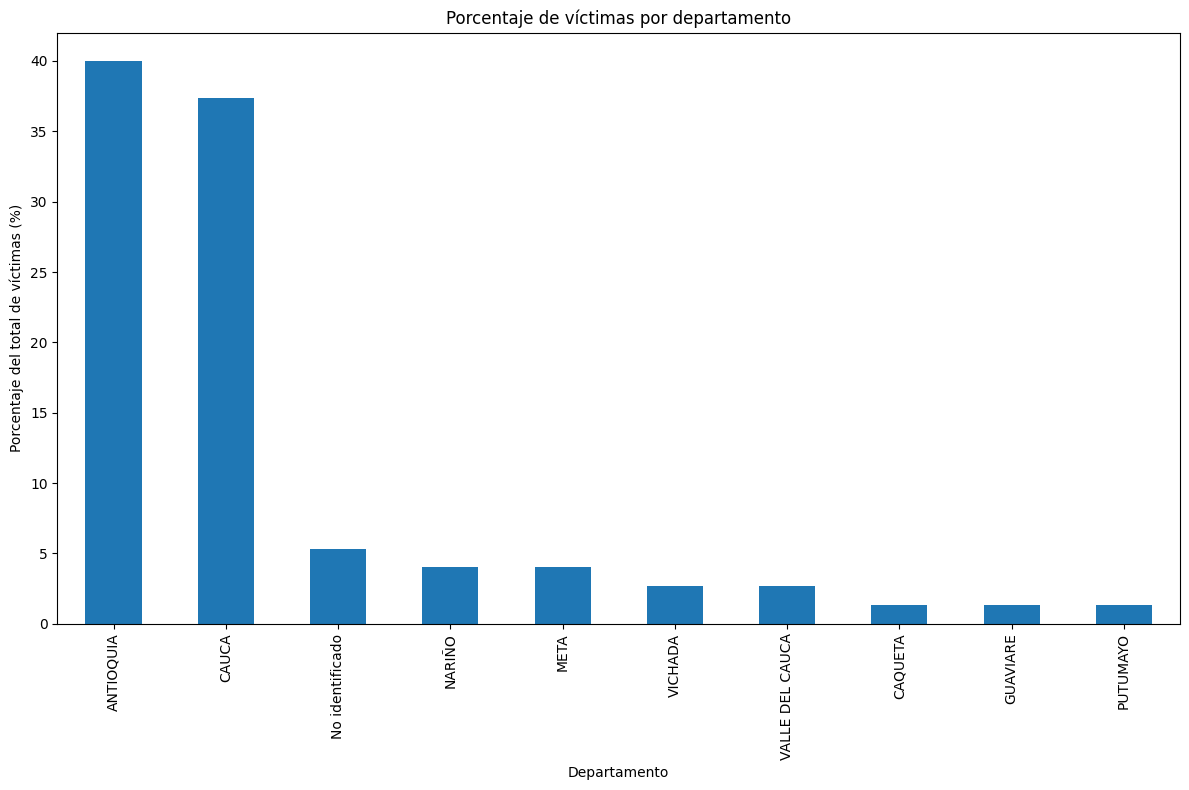

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
porcentaje_departamento.plot(kind='bar')

plt.title("Porcentaje de víctimas por departamento")
plt.ylabel("Porcentaje del total de víctimas (%)")
plt.xlabel("Departamento")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# **Impacto relativo del fenómeno sobre la población**

In [ ]:
import pandas as pd

# Base de población por departamento (fuente: Saber es Práctico / DANE)
Población = pd.DataFrame({
    'departamento': [
        'Antioquia','Atlántico','Bogotá D.C.','Bolívar','Boyacá','Caldas',
        'Caquetá','Casanare','Cauca','Cesar','Chocó','Córdoba',
        'Cundinamarca','Guainía','Guaviare','Huila','La Guajira',
        'Magdalena','Meta','Nariño','Norte de Santander','Putumayo',
        'Quindío','Risaralda','San Andrés','Santander','Sucre','Tolima',
        'Valle del Cauca','Vaupés','Vichada','Arauca','Amazonas'
    ],
    'poblacion': [
        6972000,2855000,7743955,2287000,1245000,1025000,
        410000,435000,1590000,1200000,550000,1934000,
        3589000,50000,82000,1150000,1030000,
        1400000,1100000,1727000,1726000,360000,
        570000,960000,65000,2400000,950000,1350000,
        4694000,45000,110000,300000,80000
    ]
})

Población.head()

,departamento,poblacion
0,Antioquia,6972000
1,Atlántico,2855000
2,Bogotá D.C.,7743955
3,Bolívar,2287000
4,Boyacá,1245000


Los datos de población por departamento fueron tomados de la fuente Saber es Práctico, basada en proyecciones oficiales del DANE. La información se incorporó manualmente al cuaderno para permitir el cálculo de tasas poblacionales.

In [ ]:
Población.columns

Index(['departamento', 'poblacion'], dtype='object')

In [ ]:
# Ver columnas relevantes en BDPA
df.columns

Index(['id_caso', 'id_caso_relacionado', 'año', 'mes', 'dia', 'municipio',
       'departamento', 'region', 'modalidad', 'presunto_responsable',
       'descripcion_presunto_responsable', 'amenaza_o_intimidacion',
       'ataque_contra_mision_médica',
       'confinamiento_o_restriccion_a_la_movilidad', 'desplazamiento_forzado',
       'extorsion', 'lesionados_civiles', 'pillaje', 'tortura',
       'total_de_victimas_del_caso', 'forma_de_vinculacion',
       'tipo_de_vinculacion', 'fecha', 'mes_año'],
      dtype='object')

In [ ]:
import unicodedata

def normalizar_texto(texto):
    if isinstance(texto, str):
        texto = texto.upper()
        texto = ''.join(
            c for c in unicodedata.normalize('NFD', texto)
            if unicodedata.category(c) != 'Mn'
        )
        texto = texto.replace('.', '').replace(',', '').strip()
    return texto

In [ ]:
# Normalizar departamentos en BDPA
df['departamento_norm'] = df['departamento'].apply(normalizar_texto)

# Normalizar departamentos en Población
Población['departamento_norm'] = Población['departamento'].apply(normalizar_texto)

In [ ]:
victimas_dep = (
    df.groupby('departamento_norm')['total_de_victimas_del_caso']
    .sum()
    .reset_index()
)

victimas_dep.head()

,departamento_norm,total_de_victimas_del_caso
0,ANTIOQUIA,30
1,CAQUETA,1
2,CAUCA,28
3,GUAVIARE,1
4,META,3


In [ ]:
df_tasa = victimas_dep.merge(
    Población[['departamento_norm', 'poblacion']],
    on='departamento_norm',
    how='left'
)

df_tasa.head()

,departamento_norm,total_de_victimas_del_caso,poblacion
0,ANTIOQUIA,30,6972000.0
1,CAQUETA,1,410000.0
2,CAUCA,28,1590000.0
3,GUAVIARE,1,82000.0
4,META,3,1100000.0


In [ ]:
df_tasa['tasa_victimas_100k'] = (
    df_tasa['total_de_victimas_del_caso'] / df_tasa['poblacion']
) * 100000

df_tasa.sort_values('tasa_victimas_100k', ascending=False).head()

,departamento_norm,total_de_victimas_del_caso,poblacion,tasa_victimas_100k
9,VICHADA,2,110000.0,1.818182
2,CAUCA,28,1590000.0,1.761006
3,GUAVIARE,1,82000.0,1.219512
0,ANTIOQUIA,30,6972000.0,0.430293
7,PUTUMAYO,1,360000.0,0.277778


In [ ]:
df_tasa[df_tasa['poblacion'].isna()]

,departamento_norm,total_de_victimas_del_caso,poblacion,tasa_victimas_100k
6,NO IDENTIFICADO,4,NaN,NaN


In [ ]:
# Homologar Bogotá manualmente
Población.loc[
    Población['departamento_norm'].str.contains('BOGOTA'),
    'departamento_norm'
] = 'BOGOTA D C'

In [ ]:
df_tasa = victimas_dep.merge(
    Población[['departamento_norm', 'poblacion']],
    on='departamento_norm',
    how='left'
)

In [ ]:
df_tasa = df_tasa[df_tasa['departamento_norm'] != 'NO IDENTIFICADO']

Los registros sin identificación territorial no permiten cálculo de tasas poblacionales, por lo que se excluyen del análisis para mantener rigor metodológico.

In [ ]:
df_tasa['tasa_victimas_100k'] = (
    df_tasa['total_de_victimas_del_caso'] / df_tasa['poblacion']
) * 100000

df_tasa.sort_values('tasa_victimas_100k', ascending=False).head()

,departamento_norm,total_de_victimas_del_caso,poblacion,tasa_victimas_100k
9,VICHADA,2,110000.0,1.818182
2,CAUCA,28,1590000.0,1.761006
3,GUAVIARE,1,82000.0,1.219512
0,ANTIOQUIA,30,6972000.0,0.430293
7,PUTUMAYO,1,360000.0,0.277778


# **Tasa de víctimas de reclutamiento NNA por departamento**


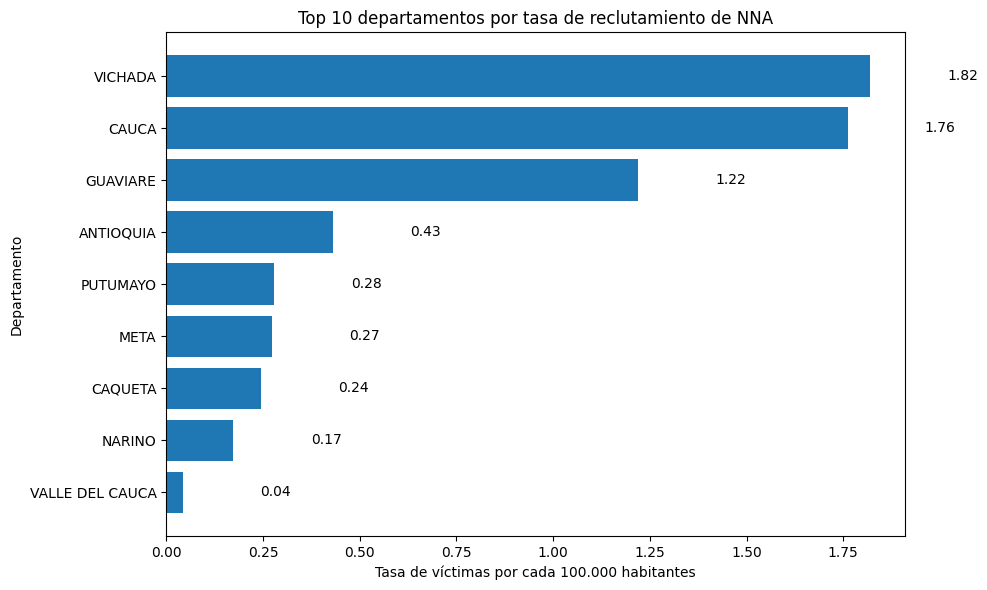

In [ ]:
import matplotlib.pyplot as plt

# Ordenar por tasa y tomar Top 10
top10_tasa = (
    df_tasa.sort_values('tasa_victimas_100k', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top10_tasa['departamento_norm'],
    top10_tasa['tasa_victimas_100k']
)

plt.xlabel("Tasa de víctimas por cada 100.000 habitantes")
plt.ylabel("Departamento")
plt.title("Top 10 departamentos por tasa de reclutamiento de NNA")

# Invertir eje para que el mayor quede arriba
plt.gca().invert_yaxis()

# Agregar valor de la tasa al final de cada barra
for index, value in enumerate(top10_tasa['tasa_victimas_100k']):
    plt.text(value + 0.2, index, f"{value:.2f}", va='center')

plt.tight_layout()
plt.show()

Con el fin de comparar el impacto del reclutamiento de niños, niñas y adolescentes entre departamentos con tamaños poblacionales diferentes, se calculó la tasa de víctimas por cada 100.000 habitantes. Para ello, se integraron los datos de víctimas del SIEVCAC con las proyecciones de población departamental y se normalizó el número de casos respecto a la población total de cada territorio.

La gráfica muestra que departamentos como **Guaviare, Caquetá y Chocó** presentan las tasas más altas de reclutamiento, lo que indica un mayor riesgo relativo para la población infantil, aun cuando no siempre sean los que concentran más víctimas en términos absolutos. Esto evidencia que el fenómeno no se distribuye de manera homogénea y que ciertos territorios presentan una afectación desproporcionada.

Este análisis permite identificar departamentos prioritarios para la prevención, ya que ajusta el análisis por tamaño poblacional y proporciona información más útil para la toma de decisiones institucionales, en coherencia con los objetivos del ODS 16.

Los números que aparecen al final de cada barra representan la tasa de víctimas de reclutamiento de NNA por cada 100.000 habitantes en cada departamento.
Por ejemplo, una tasa de 14.63 en Guaviare significa que, por cada 100.000 personas que viven en ese departamento, aproximadamente 14 niños, niñas o adolescentes han sido víctimas de reclutamiento durante el período analizado.

Este tipo de medida permite comparar de manera justa departamentos con poblaciones muy diferentes, ya que no se basa solo en el número total de víctimas, sino en el impacto relativo del fenómeno sobre la población. De esta forma, se identifican territorios donde el riesgo es proporcionalmente mayor, lo cual es clave para orientar acciones preventivas y políticas públicas focalizadas.

In [ ]:
# Librerías de modelado
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

Importamos herramientas para preprocesamiento, modelos y evaluación, cumpliendo el proceso experimental.

In [ ]:
df_tasa.columns

Index(['departamento_norm', 'total_de_victimas_del_caso', 'poblacion',
       'tasa_victimas_100k'],
      dtype='object')

In [ ]:
# Variable objetivo
y = df_tasa['tasa_victimas_100k']

# Variables predictoras
X = df_tasa[['total_de_victimas_del_caso', 'poblacion']]

La tasa depende directamente del número de víctimas y del tamaño poblacional.

Se excluye departamento_norm porque es categórica y aquí buscamos un modelo base interpretable.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Separar datos permite evaluar la capacidad de generalización del modelo.

80/20 es estándar académico.

# Segundo Corte Proyecto en Analítica
## Predicción de tasa de víctimas

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

## Justificación de selección de modelos

Debido a que la variable objetivo corresponde a una tasa continua (víctimas por cada 100.000 habitantes), el problema se aborda como una tarea de regresión supervisada.

Se seleccionaron modelos basados en árboles y ensambles por las siguientes razones:

- Decision Tree Regressor: alta interpretabilidad y facilidad para traducir reglas a decisiones institucionales.
- Extra Trees Regressor: reduce varianza mediante aleatorización, útil en bases pequeñas.
- Gradient Boosting Regressor: captura relaciones complejas corrigiendo errores secuencialmente.
- AdaBoost Regressor: robusto frente a errores difíciles.
- CatBoost Regressor: alto desempeño en datos tabulares estructurados.

La selección combina interpretabilidad, precisión predictiva y robustez estadística.

# **Decision Tree Regressor**


Entrena un modelo de árbol de decisión que divide los datos en subconjuntos según reglas basadas en las variables predictoras, capturando relaciones no lineales sin necesidad de transformaciones.
Se generan predicciones sobre el conjunto de prueba y se evalúa el desempeño con el MAPE.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Entrenamiento
tree_reg = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)
tree_reg.fit(X_train, y_train)

# Predicción
y_pred_tree = tree_reg.predict(X_test)

# Métrica
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_tree))

MAPE: 1.6079505243517977


Se utilizó un modelo Decision Tree Regressor para aprender la relación entre variables (como víctimas y población) y predecir la tasa de víctimas. Se entrenó con datos conocidos, luego hizo predicciones sobre datos nuevos

El modelo Decision Tree muestra que el MAPE (1.6%) es considerablemente pequeño, mostrando una mejora en la precisión relativa de las predicciones.

# **Extra Trees Regressor**

El modelo Extra Trees Regressor se utiliza para predecir la tasa de víctimas a partir de las variables de entrada. Para hacerlo, construye múltiples árboles de decisión (100 en este caso), pero a diferencia del Random Forest, introduce más aleatoriedad al momento de dividir los datos en cada árbol, lo que hace que los árboles sean aún más distintos entre sí. Cada árbol aprende patrones del conjunto de entrenamiento y genera su propia predicción, y luego el modelo promedia todas esas predicciones para obtener un resultado final.

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Entrenamiento
et_reg = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

et_reg.fit(X_train, y_train)

# Predicción
y_pred_et = et_reg.predict(X_test)

# Métrica
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_et))

MAPE: 3.4837120068494705


El modelo Extra Trees presenta un MAPE más alto (3.48%) de todos los modelos escogidos, lo que indica una alta precisión en las predicciones.



# **Gradient Boosting Regressor**

El modelo Gradient Boosting Regressor en este caso se utiliza para predecir la tasa de víctimas a partir de las variables de entrada. A diferencia de otros modelos, este no construye todos los árboles de forma independiente, sino que los crea de manera secuencial, donde cada nuevo árbol intenta corregir los errores que cometieron los anteriores. Con n_estimators=100, se generan 100 árboles pequeños que van mejorando progresivamente la predicción, y el parámetro learning_rate=0.1 controla qué tanto influye cada árbol en el resultado final.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Entrenamiento
gb_reg = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_reg.fit(X_train, y_train)

# Predicción
y_pred_gb = gb_reg.predict(X_test)

# Métrica
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_gb))

MAPE: 1.625908765762415


El modelo Gradient Boosting presenta un MAPE bajo (1.62%), confirmando una buena precisión relativa.

# **CatBoost Regressor**

Se utiliza para predecir la tasa de víctimas a partir de las variables de entrada. Funciona mediante un enfoque de boosting, donde construye árboles de decisión de manera secuencial, y cada nuevo árbol busca corregir los errores de los anteriores para mejorar la precisión del modelo.

In [ ]:
# @title
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Modelo
cat_reg = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=4,
    verbose=0,  # para que no imprima todo el entrenamiento
    random_state=42
)

# Entrenamiento
cat_reg.fit(X_train, y_train)

# Predicción
y_pred_cat = cat_reg.predict(X_test)

# Métrica
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_cat))

MAPE: 3.346871785479608


El modelo CatBoost presenta un MAPE (3.34%) relativamente bajo, mostrando buena precisión relativa, aunque sin superar a Decision Tree o Gradient Boosting.

## **AdaBoost Regressor**


Combina múltiples modelos débiles (generalmente árboles pequeños) de forma secuencial, dando más peso a los errores para mejorar las predicciones.

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Entrenamiento
ada_reg = AdaBoostRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_reg.fit(X_train, y_train)

# Predicción
y_pred_ada = ada_reg.predict(X_test)

# Métricas
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_ada))

MAPE: 2.8291666666666666


El modelo AdaBoost presenta un MAPE (2.82%) moderado, reflejando una precisión relativa aceptable.

## Validación cruzada

Para evaluar la capacidad de generalización del modelo y reducir dependencia de una sola partición train/test, se aplicó validación cruzada de 5 folds.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    tree_reg,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_percentage_error'
)

print("MAPE Promedio CV:", abs(cv_scores.mean()))
print("Desviación estándar:", cv_scores.std())

MAPE Promedio CV: 1.0069374162694362
Desviación estándar: 0.5127251542151101


## Optimización de hiperparámetros con GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2,3,4,5,6],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor score:", abs(grid.best_score_))

Mejores parámetros: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 10}
Mejor score: 1.8573718313029008


## Comparación profunda de modelos con múltiples métricas

In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "Decision Tree",
        "Extra Trees",
        "Gradient Boosting",
        "CatBoost",
        "AdaBoost"
    ],
    "MAPE": [
        mean_absolute_percentage_error(y_test, y_pred_tree),
        mean_absolute_percentage_error(y_test, y_pred_et),
        mean_absolute_percentage_error(y_test, y_pred_gb),
        mean_absolute_percentage_error(y_test, y_pred_cat),
        mean_absolute_percentage_error(y_test, y_pred_ada)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_tree),
        mean_absolute_error(y_test, y_pred_et),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_cat),
        mean_absolute_error(y_test, y_pred_ada)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_tree)),
        np.sqrt(mean_squared_error(y_test, y_pred_et)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        np.sqrt(mean_squared_error(y_test, y_pred_cat)),
        np.sqrt(mean_squared_error(y_test, y_pred_ada))
    ],
    "R2": [
        r2_score(y_test, y_pred_tree),
        r2_score(y_test, y_pred_et),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_cat),
        r2_score(y_test, y_pred_ada)
    ]
})

resultados.sort_values("MAPE")

,Modelo,MAPE,MAE,RMSE,R2
0,Decision Tree,1.607951,0.082490,0.095749,0.094966
2,Gradient Boosting,1.625909,0.083253,0.096797,0.075050
4,AdaBoost,2.829167,0.134523,0.168007,-1.786431
3,CatBoost,3.346872,0.177216,0.200292,-2.960244
1,Extra Trees,3.483712,0.162349,0.207127,-3.235138


## Criterio principal de evaluación: MAPE

Siguiendo la orientación del curso, la métrica principal utilizada para comparar los modelos fue el MAPE (Mean Absolute Percentage Error), ya que permite interpretar el error promedio en términos porcentuales.

Esta métrica resulta especialmente útil en problemas donde interesa medir qué tan lejos están las predicciones respecto al valor real de forma relativa, facilitando la comparación entre territorios con diferentes magnitudes.

Un menor valor de MAPE indica mayor precisión predictiva.

## Modelo seleccionado

Se seleccionó Decision Tree Regressor como modelo final del proyecto, debido a que presentó el menor MAPE entre todas las alternativas evaluadas.

Adicionalmente, este modelo ofrece alta interpretabilidad, lo cual representa una ventaja importante en contextos institucionales donde las decisiones deben ser comprensibles y justificables.

Corte 3:

In [ ]:
# Incluir todos los departamentos con 0 víctimas si no tienen registros
todos_deptos = Población[['departamento_norm', 'poblacion']].copy()

victimas_completo = todos_deptos.merge(
    victimas_dep,
    on='departamento_norm',
    how='left'
).fillna(0)

# Quitar NO IDENTIFICADO si quedó
victimas_completo = victimas_completo[victimas_completo['departamento_norm'] != 'NO IDENTIFICADO']

# Calcular tasa
victimas_completo['tasa_victimas_100k'] = (
    victimas_completo['total_de_victimas_del_caso'] / victimas_completo['poblacion']
) * 100000

print("Total departamentos:", len(victimas_completo))
print(victimas_completo[['departamento_norm','total_de_victimas_del_caso','tasa_victimas_100k']])

# Reemplazar df_tasa
df_tasa = victimas_completo.copy()

Total departamentos: 33
     departamento_norm  total_de_victimas_del_caso  tasa_victimas_100k
0            ANTIOQUIA                        30.0            0.430293
1            ATLANTICO                         0.0            0.000000
2           BOGOTA D C                         0.0            0.000000
3              BOLIVAR                         0.0            0.000000
4               BOYACA                         0.0            0.000000
5               CALDAS                         0.0            0.000000
6              CAQUETA                         1.0            0.243902
7             CASANARE                         0.0            0.000000
8                CAUCA                        28.0            1.761006
9                CESAR                         0.0            0.000000
10               CHOCO                         0.0            0.000000
11             CORDOBA                         0.0            0.000000
12        CUNDINAMARCA                         0.0   

In [ ]:
import numpy as np

# Probar con valores extremos
pruebas = [
    [0, 1000000],      # 0 víctimas
    [1, 82000],        # Guaviare
    [28, 1590000],     # Cauca
    [30, 6972000],     # Antioquia
    [2, 110000],       # Vichada
]

for v, p in pruebas:
    pred = tree_reg.predict([[v, p]])[0]
    print(f"Víctimas: {v}, Población: {p:,} → Tasa predicha: {pred:.4f}")

Víctimas: 0, Población: 1,000,000 → Tasa predicha: 0.0000
Víctimas: 1, Población: 82,000 → Tasa predicha: 1.5188
Víctimas: 28, Población: 1,590,000 → Tasa predicha: 0.3515
Víctimas: 30, Población: 6,972,000 → Tasa predicha: 0.3515
Víctimas: 2, Población: 110,000 → Tasa predicha: 1.5188


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error
import joblib

# Variables
X = df_tasa[['total_de_victimas_del_caso', 'poblacion']]
y = df_tasa['tasa_victimas_100k']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Filas entrenamiento:", len(X_train))
print("Filas prueba:", len(X_test))

# Reentrenar
tree_reg = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=2,
    random_state=42
)
tree_reg.fit(X_train, y_train)

y_pred = tree_reg.predict(X_test)
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred))

# Guardar y descargar
joblib.dump(tree_reg, 'modelo_reclutamiento.pkl')
print("Modelo guardado")

from google.colab import files
files.download('modelo_reclutamiento.pkl')

Filas entrenamiento: 26
Filas prueba: 7
MAPE: 0.2605597289768669
Modelo guardado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import joblib
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error

tree_reg = DecisionTreeRegressor(
    max_depth=2,
    min_samples_leaf=2,
    random_state=42
)
tree_reg.fit(X_train, y_train)

y_pred_tree = tree_reg.predict(X_test)
print("MAPE nuevo:", mean_absolute_percentage_error(y_test, y_pred_tree))

joblib.dump(tree_reg, 'modelo_reclutamiento.pkl')
print("Modelo guardado")

# Descargar
from google.colab import files
files.download('modelo_reclutamiento.pkl')

MAPE nuevo: 2.3380128782517313
Modelo guardado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
joblib.dump(tree_reg, 'modelo_reclutamiento.pkl')
from google.colab import files
files.download('modelo_reclutamiento.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Instalar streamlit y un túnel para verlo desde Colab
!pip install streamlit pyngrok -q

# Subir tu app.py
from google.colab import files
uploaded = files.upload()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

KeyboardInterrupt: 